In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Проверим на дубликаты

In [34]:
df.duplicated().sum()

np.int64(31994)

Нашлось 31994 дубликатов. Очистим датасет от них

In [ ]:
origin_shape0 = df.shape[0]
print(f'Количество строк до очистки от дубликатов: {origin_shape0}')
df = df.drop_duplicates()
print(f'Количество строк после удаления дубликатов: {df.shape[0]}. Дубликаты составляли {((origin_shape0 - df.shape[0]) / origin_shape0 * 100):.2f}% исходного датасета.')

Количество строк до очистки от дубликатов: 119390
Количество строк после удаления дубликатов: 87396. Дубликаты составляли 26.80% исходного датасета.


### Посмотрим каждый признак

#### Hotel

In [36]:
print(f'Пропусков у признака Hotel: {df['hotel'].isnull().sum()}')

Пропусков у признака Hotel: 0


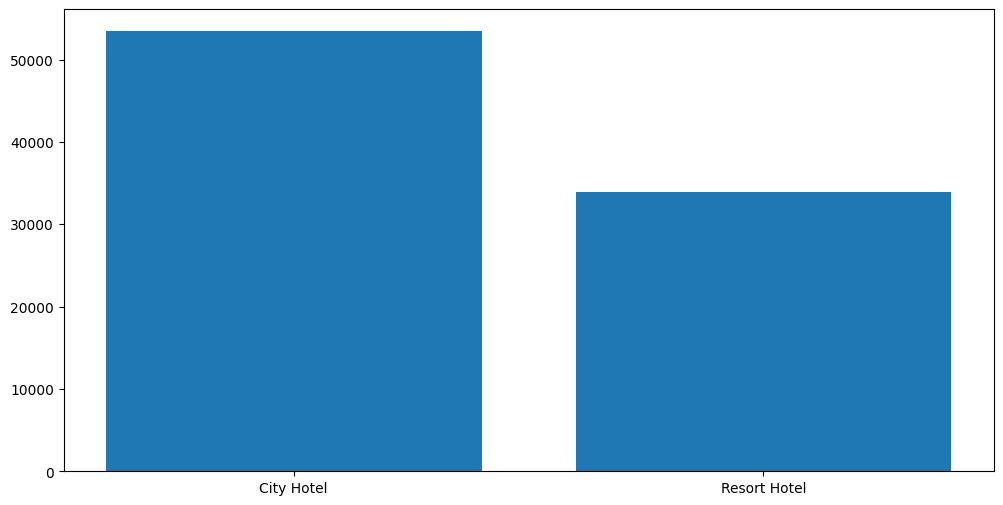

In [37]:

plt.figure(figsize=(12, 6))
plt.bar(df['hotel'].value_counts().index, df['hotel'].value_counts().values)
plt.show()

In [38]:
df['hotel'].value_counts() / df.shape[0] * 100

hotel
City Hotel      61.133233
Resort Hotel    38.866767
Name: count, dtype: float64

У нас всего два отеля: City Hotel - 61.13% и Resort Hotel - 38.87%. Пропусков нет. Можем предположить, что City Hotel более популярный в данном датасете - из-за меньшей привязки к сезонности, как, скорее всего, курортный отель - Resort Hotel. Но это будет рассмотрено уже в части анализа связи разных признаков.

#### is_canceled

In [39]:
print(f'Пропусков у признака is_canceled: {df['is_canceled'].isnull().sum()}')

Пропусков у признака is_canceled: 0


In [40]:
df['is_canceled'].value_counts() / df.shape[0] * 100

is_canceled
0    72.510184
1    27.489816
Name: count, dtype: float64

is_canceled - это основная целевая переменная - отменена ли бронь за отель. Мы видим дисбаланс классов, где не отменненых бронирований больше, но в реальности более высокое число успешных броней - нормально, почти 30% отмененных не так уж и мало.

#### lead_time

Это числовой признак, показывающий количество дней от даты внесения броня в базу, до дня прибытия 

In [41]:
print(f'Пропусков у признака lead_time: {df['lead_time'].isnull().sum()}')

Пропусков у признака lead_time: 0


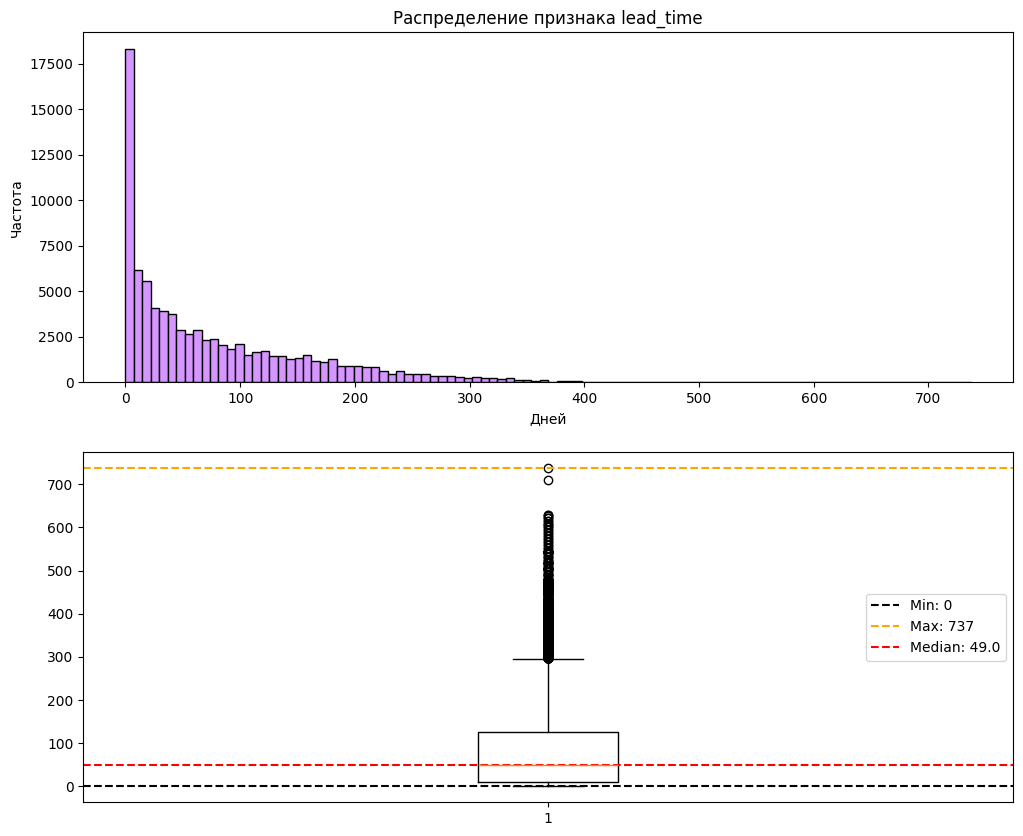

In [67]:
plt.figure(figsize=(12, 10))

plt.subplot(2,1,1)
plt.title('Распределение признака lead_time')
plt.hist(df['lead_time'], bins=100, edgecolor='black', color='#d596ff')
plt.xlabel('Дней')
plt.ylabel('Частота')

plt.subplot(2,1,2)
plt.boxplot(df['lead_time'])
plt.axhline(df['lead_time'].min(), color='black', linestyle='--', label=f'Min: {df['lead_time'].min()}')
plt.axhline(df['lead_time'].max(), color='orange', linestyle='--', label=f'Max: {df['lead_time'].max()}')
plt.axhline(df['lead_time'].median(), color='red', linestyle='--', label=f'Median: {df['lead_time'].median()}')
plt.legend()
plt.show()

#### Признаки, характеризирующие дату
Автор датасета выполнил вероятную часть нашей работы - детализировал дату на различные колонки (год, месяц, номер недели, день месяца). Посмотрим на них всех в одном блоке.

Проверим сразу все на дубликаты

In [75]:
print(f'Пропусков у признака arrival_date_year: {df['arrival_date_year'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_month: {df['arrival_date_month'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_week_number: {df['arrival_date_week_number'].isnull().sum()}')
print(f'Пропусков у признака arrival_date_day_of_month: {df['arrival_date_day_of_month'].isnull().sum()}')

Пропусков у признака arrival_date_year: 0
Пропусков у признака arrival_date_month: 0
Пропусков у признака arrival_date_week_number: 0
Пропусков у признака arrival_date_day_of_month: 0


##### arrival_date_year
Год прибытия в отель

In [25]:
df['arrival_date_year'].value_counts() / df.shape[0] * 100

arrival_date_year
2016    47.497278
2017    34.079069
2015    18.423654
Name: count, dtype: float64

У нас представлены всего 3 года, с 2015 по 2017, где самым насыщенным является 2016, а менее насыщенными 2015 и 2017 - возможно, 2015 и 2017 года представлены не полные, но это мы посмотрим далее в части анализа связей признаков.

#### arrival_date_month
Месяц прибытия в отель

In [72]:
df['arrival_date_month'].sample(10)

118054      August
39423       August
88028        April
66816        April
30114     November
35131        April
86627        April
37753         June
96383       August
10020     February
Name: arrival_date_month, dtype: str

Месяца у нас представлены в формате названия месяца на английском, без указания года и прочего

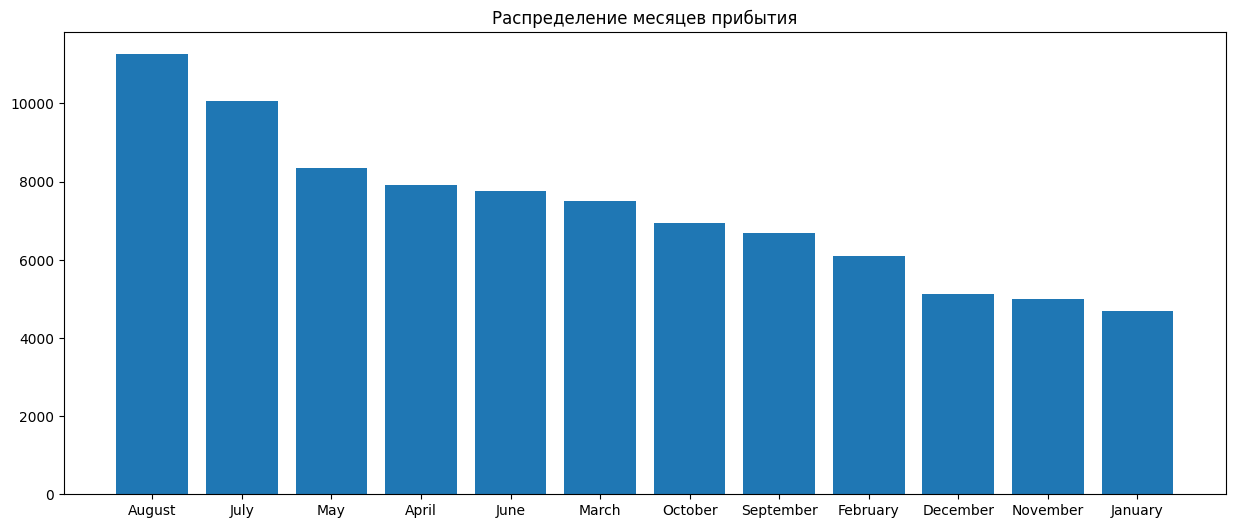

In [70]:
plt.figure(figsize=(15,6))
plt.title('Распределение месяцев прибытия')
plt.bar(df['arrival_date_month'].value_counts().index, df['arrival_date_month'].value_counts().values)
plt.show()

Самыми популярнымы оказались летние и вессение месяцы, возможно, из-за наличия Resort Hotel и в целом популярности туризма в более теплые времена года - они доминируют.

##### arrival_date_week_number
Номер недели прибытия

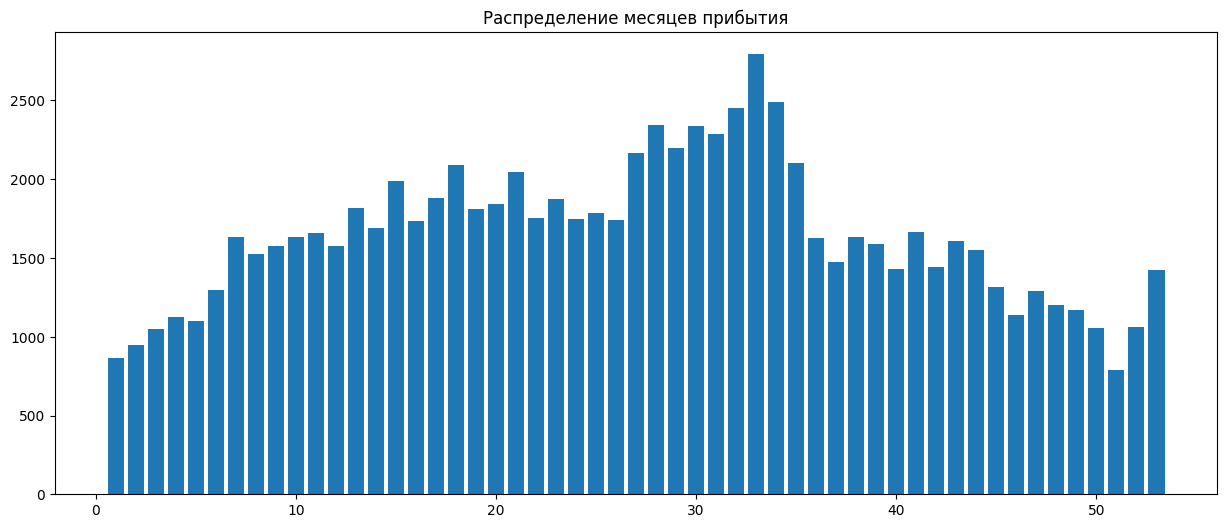

In [ ]:
plt.figure(figsize=(15,6))
plt.title('Распределение номеров недель прибытия')
plt.bar(df['arrival_date_week_number'].value_counts().index, df['arrival_date_week_number'].value_counts().values)
plt.show()

 По этому графику также видно, что около 30 недели - июль-август - как раз тоже самое, что было видно на анализе месяцев. 

##### arrival_date_day_of_month
День прибытия

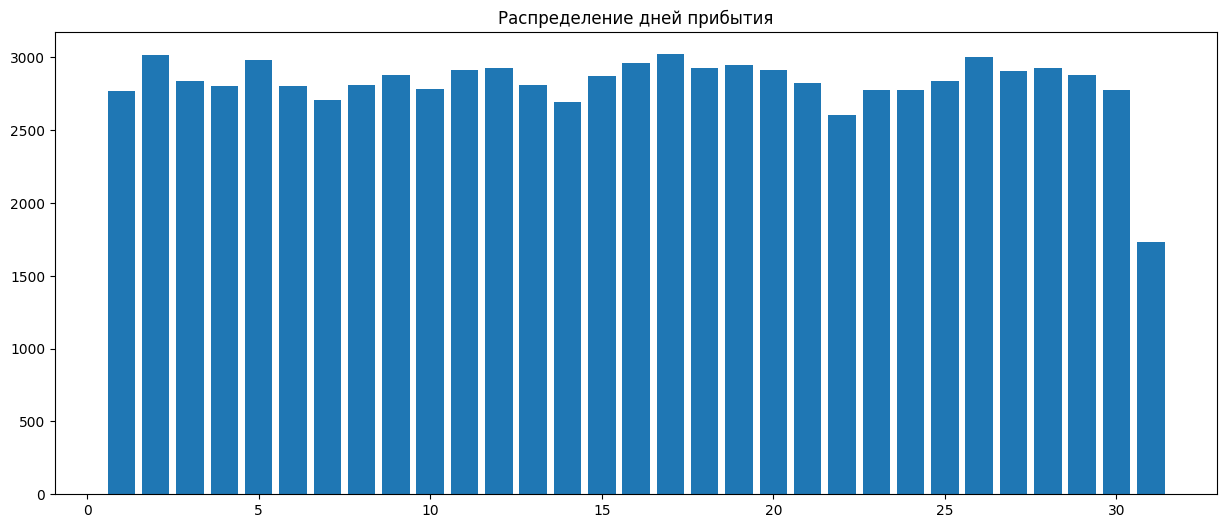

In [76]:
plt.figure(figsize=(15,6))
plt.title('Распределение дней прибытия')
plt.bar(df['arrival_date_day_of_month'].value_counts().index, df['arrival_date_day_of_month'].value_counts().values)
plt.show()

В целом во все дни примерно одинаковое количество прибытий, кроме 31 числа - таких месяцев просто меньше чем других

Следующие признаки также связы с датой, но теперь и заезда и выезда. При этом в датасете нет колонки с простой датой заезда и датой выезда. Возмиожно, так лучше, к примеру, для модели ML, но, скорее всего, нам придется вывести даты заезда и выезда самим. В любом случае посмотрим на следующие признаки.

#### stays_in_weekend_nights
Количество ночей выходных дней, в которые гости жили/бронировали

#### stays_in_week_nights
Количество ночей будних дней, в которые гости жили/бронировали

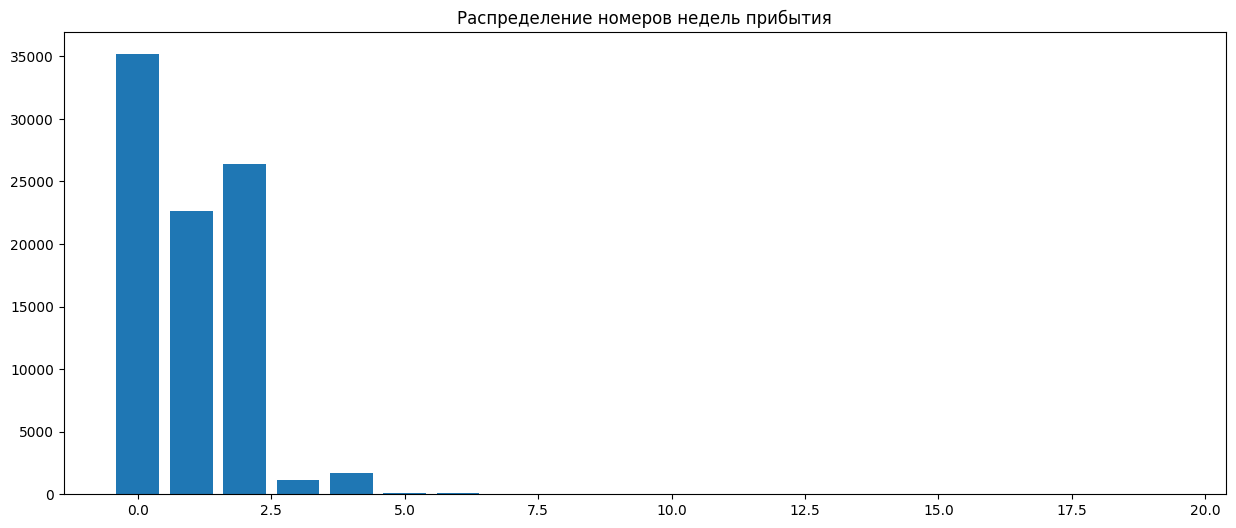

In [81]:
plt.figure(figsize=(15,6))
plt.title('Распределение номеров недель прибытия')
plt.bar(df['stays_in_weekend_nights'].value_counts().index, df['stays_in_weekend_nights'].value_counts().values)
plt.show()

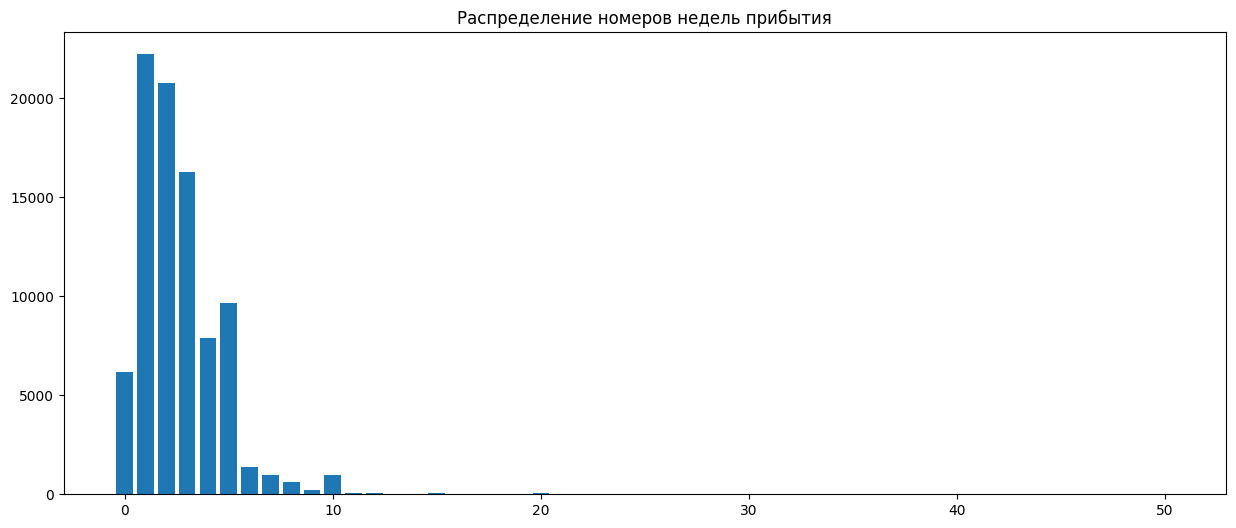

In [ ]:
plt.figure(figsize=(15,6))
plt.title('Распределение ')
plt.bar(df['stays_in_week_nights'].value_counts().index, df['stays_in_week_nights'].value_counts().values)
plt.show()

Сделующие признаки характеризуют состав гостей, а именно наличие взрослых, детей + совсем маленьких
#### adults

In [85]:
print(f'Пропусков у признака adults: {df['adults'].isnull().sum()}')

Пропусков у признака adults: 0


In [84]:
df['adults'].value_counts().sort_index()

adults
0       385
1     16503
2     64497
3      5935
4        60
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

Чаще всего, что логично, приезжают парой, из интересного - бронирования по 10, 20 и даже по 50 и 55 человек - посмотрим их

In [86]:
df[df['adults'] >= 10]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,...,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,...,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,...,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,...,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,...,No Deposit,96.0,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02


Все бронирования тут это сентябрь - октябрь 2015. При этом почти все забронированы, скорее всего, одним человеком/тур агентством, где последнее изменение статуса - 2 января 2015, кроме пары исключений и все они в итоге отменены. Наверное кто-то либо так сильно ошибся, либо это были автоматические действия. 


Эти явные выбросы есть смысл удалить, т.к. очень маловероятно, что все эти брони могли бы быть реализованы. Единственное, оставим брони, которые были сделаны не 2 января.

#### children

In [87]:
print(f'Пропусков у признака children: {df['children'].isnull().sum()}')

Пропусков у признака children: 4


У нас нашлись 4 пропуска, посмотрим их

In [ ]:
pd.options.display.max_columns = None # https://ru.hexlet.io/qna/data-analytics/questions/pandas-kak-vyvodit-vse-stolbtsy
df[df['children'].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,NaN,0,BB,PRT,Direct,Undefined,0,0,0,B,B,0,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,NaN,0,BB,PRT,Undefined,Undefined,0,0,0,B,B,0,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,NaN,0,BB,PRT,Online TA,Undefined,0,0,0,B,B,0,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [88]:
df['children'].value_counts().sort_index()

children
0.0     79028
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64

#### babies

In [94]:
print(f'Пропусков у признака babies: {df['babies'].isnull().sum()}')

Пропусков у признака babies: 0


In [95]:
df['babies'].value_counts().sort_index()

babies
0     86482
1       897
2        15
9         1
10        1
Name: count, dtype: int64

Посмотрим что за две брони с 9 и 10 младенцами

In [96]:
df[df['babies'] >= 9]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
46619,City Hotel,0,37,2016,January,3,12,0,2,2,0.0,10,BB,PRT,Online TA,TA/TO,0,0,0,D,D,1,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14
78656,City Hotel,0,11,2015,October,42,11,2,1,1,0.0,9,BB,GBR,Corporate,Corporate,0,0,0,A,B,1,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14


Эти две брони, на удивление, не отменены, причем одно из бронирований с 1 взрослым на 9 детей

 12  meal                            119390 non-null  str    
 13  country                         118902 non-null  str    
 14  market_segment                  119390 non-null  str    
 15  distribution_channel            119390 non-null  str 

#### meal
Признак, указывающий на выбранный тип питания. Обратимся к описанию категорий с информации о датасете на kaggle:
- Undefined/SC – no meal package;
- BB – Bed & Breakfast;
- HB – Half board (breakfast and one other meal – usually dinner);
- FB – Full board (breakfast, lunch and dinner)

In [97]:
print(f'Пропусков у признака meal: {df['meal'].isnull().sum()}')

Пропусков у признака meal: 0


In [99]:
df['meal'].value_counts()

meal
BB           67978
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

Можем заметить, что Undefined и SC, судя по описанию - один и тот же вариант. Переименуем в таком случае Undefined на SC

In [103]:
df.loc[df['meal'] == 'Undefined', 'meal'] = 'SC'

In [104]:
df['meal'].value_counts()

meal
BB    67978
SC     9973
HB     9085
FB      360
Name: count, dtype: int64

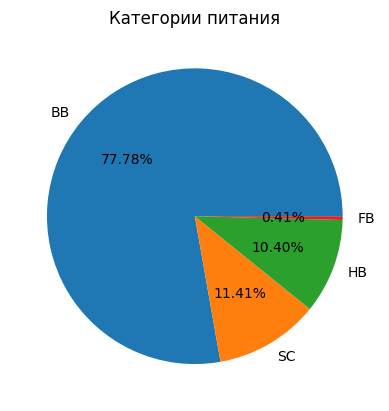

In [112]:
plt.figsize=(8, 6)

plt.title('Категории питания')
plt.pie(df['meal'].value_counts(), labels=df['meal'].value_counts().index, autopct='%.2f%%')

plt.show()

Большая часть бронирований - только завтраки. Бронирований с тремя приемами еды - вообще меньше процента

#### country
Этот признак - страна происхождения бронировавших. Судя по описанию на kaggle категории представлены в формате ISO 3155–3:2013, хотя загуглив его - ИИ от гугла в поиске говорит, что такого формата нет и, возможно, имелось в виду ISO 3166-3

In [120]:
print(f'Пропусков у признака country: {df['country'].isnull().sum()}')

Пропусков у признака country: 452


У нас достаточно много пропусков в country. Выведем рандомные 10

In [124]:
df[df['country'].isna()].sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14136,Resort Hotel,0,0,2016,March,12,15,0,1,2,0.0,0,BB,NaN,Direct,Direct,0,0,0,A,A,1,No Deposit,NaN,NaN,0,Transient,40.00,0,0,Check-Out,2016-03-16
13883,Resort Hotel,0,0,2017,January,3,16,1,0,2,0.0,0,BB,NaN,Direct,Direct,0,0,1,A,F,0,No Deposit,250.0,NaN,0,Transient,56.00,0,1,Check-Out,2017-01-17
14671,Resort Hotel,0,3,2016,April,14,1,0,1,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,1,A,D,1,No Deposit,NaN,225.0,0,Transient,45.00,0,0,Check-Out,2016-04-02
23583,Resort Hotel,0,9,2016,April,18,28,0,1,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,94.0,0,Transient-Party,39.00,1,0,Check-Out,2016-04-29
14474,Resort Hotel,0,0,2017,January,3,16,1,1,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,154.0,0,Transient,35.00,0,0,Check-Out,2017-01-18
14309,Resort Hotel,0,5,2016,June,26,21,0,2,1,0.0,0,BB,NaN,Corporate,Corporate,0,0,6,A,A,1,No Deposit,NaN,9.0,0,Transient,65.00,0,0,Check-Out,2016-06-23
14006,Resort Hotel,0,1,2015,December,51,15,0,1,2,0.0,0,BB,NaN,Corporate,Corporate,0,0,8,D,E,0,No Deposit,NaN,204.0,0,Transient,35.00,0,1,Check-Out,2015-12-16
14543,Resort Hotel,0,27,2016,September,37,8,0,2,2,0.0,0,BB,NaN,Direct,Direct,0,0,2,A,A,1,No Deposit,250.0,NaN,0,Transient,88.29,0,1,Check-Out,2016-09-10
14564,Resort Hotel,0,2,2017,March,9,4,0,1,2,0.0,0,BB,NaN,Direct,TA/TO,0,0,4,D,D,0,No Deposit,250.0,NaN,0,Transient,68.00,0,2,Check-Out,2017-03-05
14496,SC,0,40,2017,January,3,16,1,2,1,0.0,0,SC,NaN,Groups,Direct,0,0,0,A,D,1,No Deposit,NaN,NaN,0,Transient-Party,55.00,0,0,Check-Out,2017-01-19


In [115]:
df['country'].value_counts()[0:10]

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

Но здесь мы видим трехбуквенные (самые распространенные) обозначения стран (хотя этот ISO 3155–3:2013 - четырехбуквенные, причем стран, которых уже не существует, как к примеру - СССР это будет SUHH). Скорее всего еще одна ошибочка в описании и это на деле ISO 3166-1. Посмотрим на соотношение топ 5 категорий и остальных, при этом в более понятный вид расшифруем эти 5 стран:
- PRT - Португалия
- GBR - Великобритания
- FRA - Франция
- ESP - Испания
- DEU - Германия

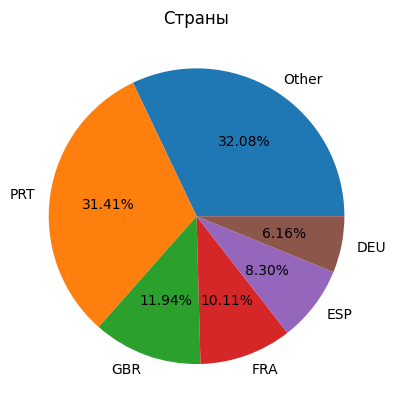

In [119]:
plt.figsize=(8, 6)

df_changed_countries = df.copy()
df_changed_countries.loc[~df['country'].isin(['PRT', 'GBR', 'FRA', 'ESP', 'DEU']), 'country'] = 'Other'

plt.title('Страны')
plt.pie(df_changed_countries['country'].value_counts(), labels=df_changed_countries['country'].value_counts().index, autopct='%.2f%%')

plt.show()

Можем заметить, что большая часть у нас из Португалии - почти треть выборки. Далее еще ряд крупных европейских государств. Можем предположить, что отель находится в Португалии - из-за чего и число бронирований оттуда наибольшее.

#### market_segment
Обозначение сегмента рынка. Описание на kaggle говорит, только о паре расшифровок: “TA” - “Турагенства", “TO” это “Туроператоры"

In [121]:
print(f'Пропусков у признака market_segment: {df['market_segment'].isnull().sum()}')

Пропусков у признака market_segment: 0


In [122]:
df['market_segment'].value_counts()

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

На вариантов значений больше чем те 2, из не упомянутых но довольно больших - разделение на онлайн и оффлайн турагенств и, для оффлайна, еше туроператоров + к этому Direct - видимо прямые брони, Groups группы и Corporate - корпоративеые

#### distribution_channel
Аналогично прошлому, но тут уже канал распространения бронирования.

In [125]:
print(f'Пропусков у признака distribution_channel: {df['distribution_channel'].isnull().sum()}')

Пропусков у признака distribution_channel: 0


In [126]:
df['distribution_channel'].value_counts()

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64